In [2]:
import geopandas as gpd

In [6]:
### Setting the data path
data_path = r'C:\Data\LearnMLAI\Applied-Geospatial-Data-Science-with-Python\Data'

# Setting the folder we want to write the output data to
out_path = r'C:\Data\LearnMLAI\Applied-Geospatial-Data-Science-with-Python\Data\Output'

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Aqwam\AppData\Local\Temp\ipykernel_20760\382204104.py:2: SyntaxWarning: invalid escape sequence '\D'
  data_path = 'C:\Data\LearnMLAI\Applied-Geospatial-Data-Science-with-Python\Data'


## Reading geospatial data with GeoPandas

In [8]:
# Reading data stored as a shapefile without specifying that it is a shapefile
capitals = gpd.read_file(data_path + r'\Graticule\ne_110m_graticules_10.shp')

In [9]:
# Reading data stored as a shapefile and specifying that it is a shapefile
capitals = gpd.read_file(data_path + r'\Graticule\ne_110m_graticules_10.shp', driver='shapefile')

c:\Data\LearnMLAI\Applied-Geospatial-Data-Science-with-Python\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver ESRI Shapefile does not support open option DRIVER
  return ogr_read(


In [10]:
# Reading from a URL
url = "https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_110m_admin_1_states_provinces_shp.geojson"
us_states = gpd.read_file(url)

In [12]:
# Reading in data stored in a zipped file
us_cbsas = gpd.read_file(data_path + r'\tl_2021_us_cbsa.zip')

### Filtering using the mask parameter

In [20]:
# Read in the US States file from the Census Tiger Files saved as a zip
us_states = gpd.read_file(data_path + r'\tl_2021_us_state.zip')

# Filter the US States file to be just California
california = us_states[us_states['NAME']=="California"] 

# Show the dataframe  
california.head()

,REGION,DIVISION,STATEFP,STATENS,GEOID,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
13,4,9,06,01779778,06,CA,California,00,G4000,A,403671756816,20293573058,+37.1551773,-119.5434183,"MULTIPOLYGON (((-116.10617 32.61848, -116.1085..."


In [15]:
# Create a new geopandas dataframe that only includes the CBSAs that are in California using the geopandas mask parameter and passing the previously defined california geopandas dataframe
ca_cbsas = gpd.read_file(data_path + r'\tl_2021_us_cbsa.zip', mask=california)

# Show the first 5 records of the ca_cbsas geopandas dataframe
ca_cbsas.head()

,CSAFP,CBSAFP,GEOID,NAME,NAMELSAD,LSAD,MEMI,MTFCC,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,NaN,12540,12540,"Bakersfield, CA","Bakersfield, CA Metro Area",M1,1,G3110,21068632654,78405068,+35.3466288,-118.7295064,"POLYGON ((-118.88168 34.81785, -118.88204 34.8..."
1,NaN,15060,15060,"Brookings, OR","Brookings, OR Micro Area",M2,2,G3110,4217489863,934614482,+42.4664387,-124.2109292,"POLYGON ((-123.82239 42.15933, -123.82246 42.1..."
2,NaN,17340,17340,"Clearlake, CA","Clearlake, CA Micro Area",M2,2,G3110,3254452700,188748214,+39.0948019,-122.7467569,"POLYGON ((-122.41579 38.768, -122.41584 38.767..."
3,NaN,18860,18860,"Crescent City, CA","Crescent City, CA Micro Area",M2,2,G3110,2606118035,578742633,+41.7499033,-123.9809983,"POLYGON ((-124.31611 41.72839, -124.33061 41.7..."
4,456,22280,22280,"Fernley, NV","Fernley, NV Micro Area",M2,2,G3110,5187939862,59489121,+39.0222125,-119.1974246,"POLYGON ((-118.9065 38.51631, -118.90649 38.51..."


In [16]:
len(ca_cbsas)

46

### Filtering using the bounding box parameter

In [22]:
# Defining the bounding box
bounding_box = (-123.82239, 42.15933, -123.82246, 38.7)

#Reading in the CA_CBSAs and filtering based on the bounding box
cbsas_bbox = gpd.read_file(data_path + r'\tl_2021_us_cbsa.zip', bbox=bounding_box)

# Showing the first 5 rows of the filtered dataframe
cbsas_bbox.head()

,CSAFP,CBSAFP,GEOID,NAME,NAMELSAD,LSAD,MEMI,MTFCC,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,NaN,15060,15060,"Brookings, OR","Brookings, OR Micro Area",M2,2,G3110,4217489863,934614482,+42.4664387,-124.2109292,"POLYGON ((-123.82239 42.15933, -123.82246 42.1..."
1,NaN,18860,18860,"Crescent City, CA","Crescent City, CA Micro Area",M2,2,G3110,2606118035,578742633,+41.7499033,-123.9809983,"POLYGON ((-124.31611 41.72839, -124.33061 41.7..."
2,NaN,21700,21700,"Eureka-Arcata, CA","Eureka-Arcata, CA Micro Area",M2,2,G3110,9241565229,1253726036,+40.7066554,-123.9261757,"POLYGON ((-124.36704 40.67227, -124.3608 40.68..."
3,366,24420,24420,"Grants Pass, OR","Grants Pass, OR Metro Area",M1,1,G3110,4244080762,5631773,+42.3869829,-123.5716197,"POLYGON ((-123.23109 42.12807, -123.23108 42.1..."
4,NaN,46380,46380,"Ukiah, CA","Ukiah, CA Micro Area",M2,2,G3110,9082632466,961740401,+39.4323876,-123.4428811,"POLYGON ((-123.23896 38.80856, -123.24382 38.8..."


## Writing geospatial data with GeoPandas

In [25]:
# Writing out the data as a shape file
ca_cbsas.to_file(out_path+r"\ca_cbsas.shp")

In [26]:
# Writing out the data as a shape file
cbsas_bbox.to_file(out_path+r"\cbsas_bbox.geojson", driver="GeoJSON")

## Geometric Manipulations

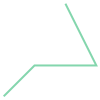

In [32]:
from shapely.geometry import Point, LineString, Polygon

s = gpd.GeoSeries(
    [
        Point(1, 5),
        LineString([(2, -1), (3, 0), (5, 0), (4, 2)]),
        Polygon([(5, -2), (3, 5), (5, 2)]),
    ]
)

s[1]

### Performing Buffer

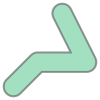

In [33]:
s_b = s.buffer(.4)
s_b[1]

### Performing a dissolve operation

<Axes: >

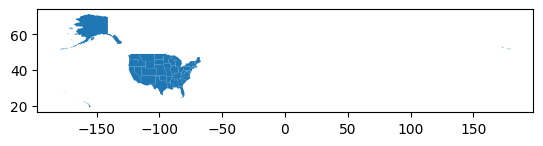

In [38]:
us_states = gpd.read_file(data_path + r'\tl_2021_us_state.zip')

# Filtering out territories 
us_states = us_states[~us_states['STUSPS'].isin(['MP','VI','GU','AS','PR'])]

# Setting the PCS
us_states = us_states.to_crs('EPSG:4326')
us_states.plot()

<Axes: >

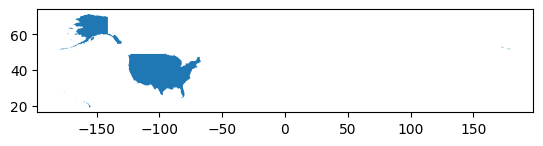

In [39]:
us_states_d = us_states.dissolve()
us_states_d.plot()

### Simplifying the geometry

<Axes: >

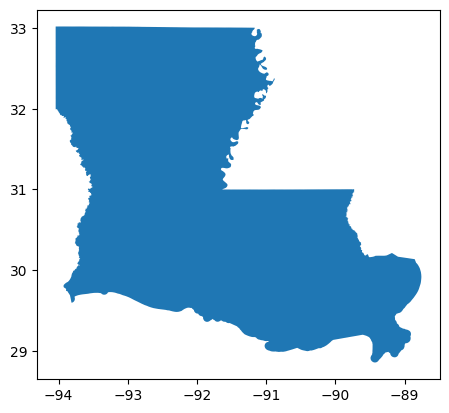

In [40]:
LA = us_states[us_states['STUSPS']=='LA']
LA.plot()

<Axes: >

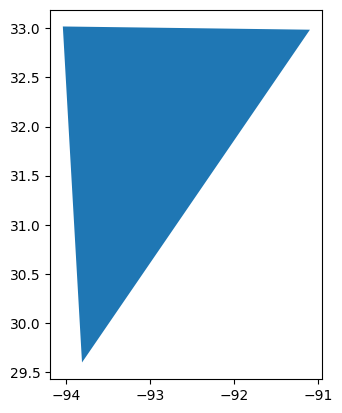

In [41]:
LA_s = LA.simplify(tolerance=10000)
LA_s.plot()

## Ploting Geospatial Data

<Axes: >

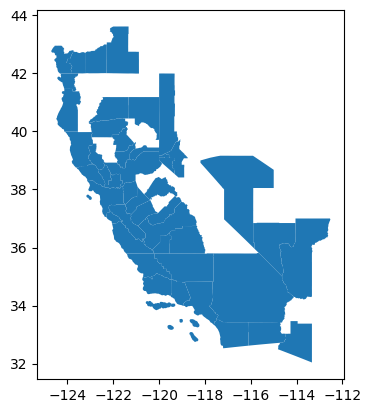

In [43]:
# Basic map of California CBSAs
ca_cbsas.plot()

<Axes: >

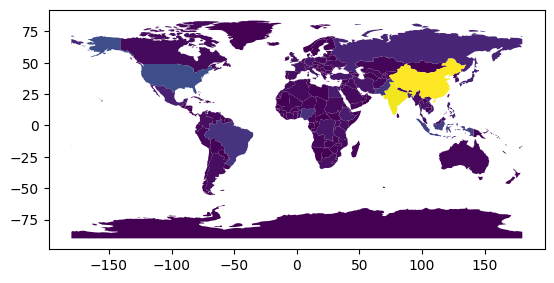

In [45]:
# Choropleth Map of the world's population 

# Reading in the natural earth lowres data
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Plotting the data colored by the pop_est GeoSeries
world.plot(column='POP_EST')

In [31]:
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [47]:
continents = world.dissolve(by="CONTINENT")
continents.head()

,geometry,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,...,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA
CONTINENT,,,,,,,,,,,,,,,,,,,,,
Africa,"MULTIPOLYGON (((-11.43878 6.78592, -11.70819 6...",Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,...,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized
Antarctica,"MULTIPOLYGON (((-61.13898 -79.98137, -60.61012...",Admin-0 country,1,4,Antarctica,ATA,0,2,Indeterminate,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Asia,"MULTIPOLYGON (((48.67923 14.0032, 48.23895 13....",Admin-0 country,1,3,Kazakhstan,KA1,1,1,Sovereignty,1,...,Unrecognized,Admin-0 country,Admin-1 states provinces,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized
Europe,"MULTIPOLYGON (((-53.55484 2.3349, -53.77852 2....",Admin-0 country,1,2,Russia,RUS,0,2,Sovereign country,1,...,Unrecognized,Admin-0 country,Unrecognized,Admin-0 country,Unrecognized,Admin-0 country,Admin-0 country,Admin-0 country,Admin-0 country,Unrecognized
North America,"MULTIPOLYGON (((-155.22217 19.23972, -155.5421...",Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

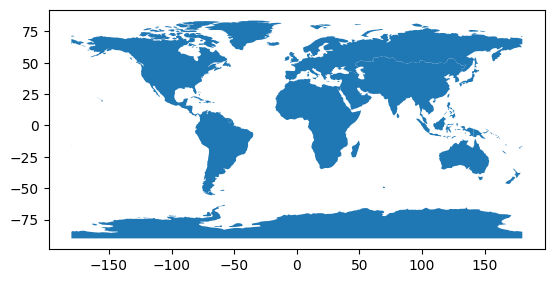

In [48]:
continents.plot()

### Geocoding

In [49]:
import pandas as pd
dc_attractions = pd.read_csv(data_path + r'\DC_Attractions.csv')
dc_attractions.head()

,Attraction,Address
0,Washington Monument,"2 15th St NW, Washington, DC 20024"
1,Smithsonian National Air and Space Museum,"600 Independence Ave SW, Washington, DC 20560"
2,White House,"1600 Pennsylvania Avenue NW, Washington, DC 20500"


In [50]:
from geopandas.tools import geocode

# Geocode addresses using Nominatim. Remember to provide a custom "application name" in the user_agent parameter!
dc_attractions_gpd = geocode(dc_attractions['Address'], provider='openmapquest', timeout=4, api_key="API KEY")
dc_attractions_gpd.head()

GeocoderUnavailable: HTTPSConnectionPool(host='open.mapquestapi.com', port=443): Max retries exceeded with url: /nominatim/v1/search?q=2+15th+St+NW%2C+Washington%2C+DC+20024&format=json&limit=1&key=API+KEY (Caused by NameResolutionError("HTTPSConnection(host='open.mapquestapi.com', port=443): Failed to resolve 'open.mapquestapi.com' ([Errno 11001] getaddrinfo failed)"))

In [ ]:
dc_attractions_gpd.plot()